# GalaxEye EO-SAR Binary Change Detection
## AI Research Intern Technical Assignment

**Author:** Sakthivel  
**Date:** May 13, 2026  
**Role Applied:** AI Research Intern  

---

# 📊 Final Results Summary

| Metric | Validation | Test |
|--------|------------|------|
| **IoU** | 0.1911 | **0.0601** |
| **F1 Score** | 0.3209 | **0.1133** |
| **Precision** | 0.0823 | **0.0700** |
| **Recall** | 0.5220 | **0.2969** |
| **False Positives** | - | **2,402,584** |

### ✅ Best Configuration
- **Best Epoch:** 21
- **Best Threshold:** 0.70
- **Inference:** Sliding Window + TTA
- **GPU Used:** NVIDIA T4/A100

---
# 🏗️ Architecture Overview

                ┌───────────────────────┐
                │   EO Image (3-ch)     │
                └──────────┬────────────┘
                           │
                           ▼
                ┌───────────────────────┐
                │   ResNet34 Encoder    │
                └──────────┬────────────┘
                           │
                           │
                           ▼
                    ┌────────────┐
                    │  Feature   │
                    │   Fusion   │
                    └──────┬─────┘
                           │
                           ▼
                    ┌────────────┐
                    │   UNet     │
                    │  Decoder   │
                    └─────┬──────┘
                           │
                           ▼
                    ┌────────────┐
                    │ Change Mask│
                    └────────────┘


                ┌───────────────────────┐
                │  SAR Image (1-ch)     │
                └──────────┬────────────┘
                           │
                           ▼
                ┌───────────────────────┐
                │   ResNet18 Encoder    │
                │   + InstanceNorm      │
                └───────────────────────┘

### Key Components
- Dual-encoder UNet architecture
- Pretrained ImageNet backbone weights
- Instance Normalization for SAR domain adaptation
- Focal + Dice hybrid loss
- Scene-balanced weighted sampler
- Sliding window inference (512 crop / 384 stride)
- Test Time Augmentation (4-flip averaging)

---

# 🔑 Key Findings

1. Significant SAR domain shift exists between training and test scenes.
2. Epoch 21 generalized better than later epochs.
3. Threshold optimization improved IoU and reduced false positives.
4. Increasing threshold from 0.50 → 0.70 reduced FP by ~56%.

---

# ⚙️ Training Configuration

| Parameter | Value |
|---|---|
| Epochs | 30 |
| Batch Size | 4 |
| Gradient Accumulation | 4 |
| Encoder LR | 1e-4 |
| Decoder LR | 3e-4 |
| Crop Size | 512 |
| Optimizer | AdamW |
| Scheduler | CosineAnnealingLR |

---

# 📁 Generated Files

| File | Description |
|---|---|
| `ep21.pth` | Best trained model |
| `training_history.png` | Training curves |
| `submission_metrics.txt` | Final evaluation metrics |

---

# 🚀 Execution

1. Enable GPU runtime (T4/A100)
2. Run notebook cells sequentially
3. Total training time ≈ 3.5 hours
4. Final metrics generated automatically

---

In [ ]:
# ─────────────────────────────────────────────
# CELL 1 — Check GPU
# ─────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), 'GPU not found! Change runtime to GPU.'
print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


In [ ]:
# ─────────────────────────────────────────────
# CELL 2 — Install dependencies
# ─────────────────────────────────────────────
!pip install -q rasterio scikit-image huggingface_hub datasets scipy
print('All dependencies installed.')

All dependencies installed.


In [ ]:
# ─────────────────────────────────────────────
# CELL 3 — Mount Drive + Download Data
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, zipfile
from huggingface_hub import snapshot_download

SAVE_DIR  = '/content/drive/MyDrive/galaxeye_checkpoints'
DATA_ROOT = '/content/galaxeye_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Download dataset from HuggingFace
shutil.rmtree(DATA_ROOT, ignore_errors=True)
snapshot_download(
    repo_id='doron333/change-detection-dataset',
    repo_type='dataset',
    local_dir=DATA_ROOT,
    ignore_patterns=['*.git*']
)

for split in ['train', 'val', 'test']:
    zpath = f'{DATA_ROOT}/{split}.zip'
    if os.path.exists(zpath):
        with zipfile.ZipFile(zpath) as z:
            z.extractall(DATA_ROOT)
        print(f'{split} extracted')
    else:
        print(f'{split}.zip not found — checking if already extracted')

print('Data ready.')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

train extracted
val extracted
test extracted
Data ready.


In [ ]:
# ─────────────────────────────────────────────
# CELL 4 — CONFIG (all hyperparameters in one place)
# ─────────────────────────────────────────────
import random, numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CONFIG = {
    # Paths
    'data_root' : DATA_ROOT,
    'save_dir'  : SAVE_DIR,
    'seed'      : SEED,

    # Scene configuration
    'train_scenes'    : {'scene_01','scene_02','scene_03',
                         'scene_04','scene_05','scene_06',
                         'scene_07','scene_08'},
    'high_sar_scenes' : {'scene_06','scene_08'},

    # Training
    'epochs'       : 30,
    'batch_size'   : 4,
    'accum_steps'  : 4,
    'lr_encoder'   : 1e-4,
    'lr_decoder'   : 3e-4,
    'weight_decay' : 1e-4,
    'patience'     : 12,
    'crop_size'    : 512,
    'num_workers'  : 2,

    # Loss
    'focal_alpha'  : 0.75,
    'focal_gamma'  : 2.0,
    'focal_weight' : 0.6,
    'dice_weight'  : 0.4,

    # Sampler weights
    'sparse_weight'         : 6.0,
    'dense_weight'          : 3.0,
    'empty_weight'          : 0.0,
    'high_sar_scene_weight' : 0.3,

    # Cropping
    'adaptive_crop_prob' : 0.55,

    # Inference
    'slide_crop'   : 512,
    'slide_stride' : 384,
    'min_blob_size': 30,

    # Threshold — will be tuned on val only
    'threshold'    : 0.50,
}

print('CONFIG ready.')
for k, v in CONFIG.items():
    print(f'  {k:25s}: {v}')

CONFIG ready.
  data_root                : /content/galaxeye_data
  save_dir                 : /content/drive/MyDrive/galaxeye_checkpoints
  seed                     : 42
  train_scenes             : {'scene_04', 'scene_05', 'scene_06', 'scene_08', 'scene_07', 'scene_02', 'scene_03', 'scene_01'}
  high_sar_scenes          : {'scene_06', 'scene_08'}
  epochs                   : 30
  batch_size               : 4
  accum_steps              : 4
  lr_encoder               : 0.0001
  lr_decoder               : 0.0003
  weight_decay             : 0.0001
  patience                 : 12
  crop_size                : 512
  num_workers              : 2
  focal_alpha              : 0.75
  focal_gamma              : 2.0
  focal_weight             : 0.6
  dice_weight              : 0.4
  sparse_weight            : 6.0
  dense_weight             : 3.0
  empty_weight             : 0.0
  high_sar_scene_weight    : 0.3
  adaptive_crop_prob       : 0.55
  slide_crop               : 512
  slide_stride     

In [ ]:
# ─────────────────────────────────────────────
# CELL 5 — Dataset (FIXED with padding for val/test)
# ─────────────────────────────────────────────
import os, random, numpy as np, rasterio, torch
from torch.utils.data import Dataset, WeightedRandomSampler
from PIL import Image
from skimage import exposure


def get_scene(fname):
    """Extract scene_XX from filename like scene_06_patch_001.tif"""
    p = fname.split('_')
    return f'{p[0]}_{p[1]}'


def normalise_sar(sar):
    """
    SAR normalisation strategy:
    1. log1p to compress bright-scene dominance
    2. Per-image z-score (InstanceNorm equivalent)
    3. Clip to [-3, 3] and scale to [0, 1]
    """
    sar = np.log1p(np.clip(sar, 0, None))
    mu  = sar.mean()
    std = sar.std() + 1e-6
    sar = (sar - mu) / std
    sar = np.clip(sar, -3, 3)
    sar = (sar + 3) / 6.0
    return sar


class ChangeDetectionDataset(Dataset):
    def __init__(self, root, split='train', crop=512, scenes=None):
        self.crop     = crop
        self.split    = split
        self.is_train = (split == 'train')

        # Handle nested directory structure
        b1   = os.path.join(root, split, split)
        b2   = os.path.join(root, split)
        base = b1 if os.path.isdir(os.path.join(b1, 'pre-event')) else b2

        self.pre  = os.path.join(base, 'pre-event')
        self.post = os.path.join(base, 'post-event')
        self.tgt  = os.path.join(base, 'target')

        files = sorted([f for f in os.listdir(self.pre)
                        if f.endswith('.tif')])

        if scenes and self.is_train:
            files = [f for f in files if get_scene(f) in scenes]

        self.files  = files
        self.scenes = [get_scene(f) for f in files]
        self.info   = self._scan()

        # Filter empty patches for training
        if self.is_train:
            keep        = [i for i, d in enumerate(self.info) if d['has_damage']]
            self.files  = [self.files[i]  for i in keep]
            self.scenes = [self.scenes[i] for i in keep]
            self.info   = [self.info[i]   for i in keep]

        nd = sum(1 for d in self.info if d['has_damage'])
        ne = sum(1 for d in self.info if not d['has_damage'])
        print(f'[{split:5s}] {len(self.files)} samples | '
              f'damage={nd} empty={ne} | '
              f'scenes={sorted(set(self.scenes))}')

    def _scan(self):
        out = []
        for f in self.files:
            with rasterio.open(os.path.join(self.tgt, f)) as s:
                m = s.read(1)
            b   = (m >= 2)
            nc  = int(b.sum())
            pct = 100.0 * nc / m.size
            ys, xs = np.where(b) if nc > 0 else (None, None)
            out.append({
                'has_damage': nc > 0,
                'is_sparse' : nc > 0 and pct < 1.0,
                'coords'    : (ys, xs) if nc > 0 else None,
            })
        return out

    def get_sampler(self):
        sc  = {}
        for s in self.scenes:
            sc[s] = sc.get(s, 0) + 1
        n   = len(sc)
        tot = len(self.files)
        W   = []
        for scene, info in zip(self.scenes, self.info):
            sw = tot / (n * sc[scene])
            dw = (CONFIG['sparse_weight'] if info['is_sparse'] else
                  CONFIG['dense_weight']  if info['has_damage'] else
                  CONFIG['empty_weight'])
            hw = (CONFIG['high_sar_scene_weight']
                  if scene in CONFIG['high_sar_scenes'] else 1.0)
            W.append(sw * dw * hw)
        w = torch.tensor(W, dtype=torch.float)
        return WeightedRandomSampler(w, len(w), replacement=True)

    def __len__(self):
        return len(self.files)

    def _read(self, path):
        with rasterio.open(path) as s:
            return s.read().astype(np.float32)

    def _pad(self, *arrs, size):
        _, h, w = arrs[0].shape
        ph = max(0, size - h)
        pw = max(0, size - w)
        if ph or pw:
            arrs = [np.pad(a, ((0,0),(0,ph),(0,pw)), mode='reflect')
                    for a in arrs]
        return arrs

    def _rcrop(self, *arrs, size):
        arrs = self._pad(*arrs, size=size)
        _, h, w = arrs[0].shape
        t = random.randint(0, h - size)
        l = random.randint(0, w - size)
        return [a[:, t:t+size, l:l+size] for a in arrs]

    def _acrop(self, *arrs, size, coords):
        arrs = self._pad(*arrs, size=size)
        _, h, w = arrs[0].shape
        i  = random.randint(0, len(coords[0]) - 1)
        cy = int(coords[0][i])
        cx = int(coords[1][i])
        t  = max(0, min(cy - size // 2, h - size))
        l  = max(0, min(cx - size // 2, w - size))
        return [a[:, t:t+size, l:l+size] for a in arrs]

    def _resize(self, eo, sar, mask, s=512):
        eo2  = np.stack([np.array(Image.fromarray(eo[c]).resize(
                    (s,s), Image.BILINEAR)) for c in range(eo.shape[0])])
        sar2 = np.stack([np.array(Image.fromarray(sar[c]).resize(
                    (s,s), Image.BILINEAR)) for c in range(sar.shape[0])])
        m2   = np.array(Image.fromarray(mask[0]).resize(
                    (s,s), Image.NEAREST))[np.newaxis]
        return eo2, sar2, m2

    def _aug_sar(self, sar):
        if random.random() > 0.4:
            sar = np.clip(sar * random.uniform(0.5, 1.6), 0, 1)
        if random.random() > 0.4:
            sar = np.clip(sar + sar * np.random.normal(0, 0.07, sar.shape), 0, 1)
        if random.random() > 0.4:
            sar = np.clip(sar + random.uniform(-0.40, 0.15), 0, 1)
        if random.random() > 0.5:
            p2, p98 = np.percentile(sar, (2, 98))
            if p98 > p2:
                sar = np.clip(
                    exposure.rescale_intensity(sar, in_range=(p2, p98)), 0, 1)
        if random.random() > 0.5:
            sar = np.clip(sar ** random.uniform(0.6, 1.5), 0, 1)
        return sar

    def _aug(self, eo, sar, mask):
        if random.random() > 0.5:
            eo   = np.flip(eo,   2).copy()
            sar  = np.flip(sar,  2).copy()
            mask = np.flip(mask, 2).copy()
        if random.random() > 0.5:
            eo   = np.flip(eo,   1).copy()
            sar  = np.flip(sar,  1).copy()
            mask = np.flip(mask, 1).copy()
        k = random.randint(0, 3)
        if k:
            eo   = np.rot90(eo,   k, (1,2)).copy()
            sar  = np.rot90(sar,  k, (1,2)).copy()
            mask = np.rot90(mask, k, (1,2)).copy()
        if random.random() > 0.5:
            b = random.uniform(0.85, 1.15)
            c = random.uniform(0.85, 1.15)
            eo = np.clip((eo - 0.5) * c + 0.5, 0, 1)
            eo = np.clip(eo * b, 0, 1)
        sar = self._aug_sar(sar)
        return eo, sar, mask

    def __getitem__(self, idx):
        f    = self.files[idx]
        info = self.info[idx]

        eo   = self._read(os.path.join(self.pre,  f))
        sar  = self._read(os.path.join(self.post, f))
        mask = self._read(os.path.join(self.tgt,  f))

        eo   = np.clip(eo, 0, 255) / 255.0
        sar  = normalise_sar(sar)
        mask = np.where(mask >= 2, 1, 0).astype(np.float32)

        if self.is_train:
            size = random.choice([256, 512])
            if (info['coords'] is not None and
                    random.random() < CONFIG['adaptive_crop_prob']):
                eo, sar, mask = self._acrop(
                    eo, sar, mask, size=size, coords=info['coords'])
            else:
                eo, sar, mask = self._rcrop(eo, sar, mask, size=size)
            eo, sar, mask = self._aug(eo, sar, mask)
            if size != 512:
                eo, sar, mask = self._resize(eo, sar, mask, s=512)
        else:
            # FIX: Pad to multiple of 32 for UNet compatibility
            _, H, W = eo.shape
            pad_h = (32 - H % 32) % 32
            pad_w = (32 - W % 32) % 32
            if pad_h or pad_w:
                eo   = np.pad(eo,   ((0,0), (0,pad_h), (0,pad_w)), mode='reflect')
                sar  = np.pad(sar,  ((0,0), (0,pad_h), (0,pad_w)), mode='reflect')
                mask = np.pad(mask, ((0,0), (0,pad_h), (0,pad_w)), mode='constant', constant_values=0)

        return {
            'image': torch.from_numpy(
                np.concatenate([eo, sar], axis=0)).float(),
            'mask' : torch.from_numpy(mask).float(),
            'fname': f,
        }

print('Dataset class defined.')

Dataset class defined.


In [ ]:
# ─────────────────────────────────────────────
# CELL 6 — Model (Dual-Encoder UNet)
# ─────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision.models import resnet34, resnet18
from torchvision.models import ResNet34_Weights, ResNet18_Weights


class CBR(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class EOEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        self.c1 = r.conv1
        self.bn = r.bn1
        self.re = r.relu
        self.mp = r.maxpool
        self.l1 = r.layer1
        self.l2 = r.layer2
        self.l3 = r.layer3
        self.l4 = r.layer4

    def forward(self, x):
        feats = []
        x = self.re(self.bn(self.c1(x)));  feats.append(x)
        x = self.l1(self.mp(x));           feats.append(x)
        x = self.l2(x);                    feats.append(x)
        x = self.l3(x);                    feats.append(x)
        x = self.l4(x);                    feats.append(x)
        return feats


class SAREncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.c1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.c1.weight.data = r.conv1.weight.data.mean(1, keepdim=True)
        self.in1 = nn.InstanceNorm2d(64, affine=True)
        self.re  = nn.ReLU(inplace=True)
        self.mp  = r.maxpool
        self.l1  = r.layer1
        self.l2  = r.layer2
        self.l3  = r.layer3
        self.l4  = r.layer4

    def forward(self, x):
        feats = []
        x = self.re(self.in1(self.c1(x)));  feats.append(x)
        x = self.l1(self.mp(x));            feats.append(x)
        x = self.l2(x);                     feats.append(x)
        x = self.l3(x);                     feats.append(x)
        x = self.l4(x);                     feats.append(x)
        return feats


class DecBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, drop=0.3):
        super().__init__()
        self.c1 = nn.Sequential(CBR(in_ch + skip_ch, out_ch), nn.Dropout2d(drop))
        self.c2 = nn.Sequential(CBR(out_ch, out_ch),          nn.Dropout2d(drop))

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.c2(self.c1(torch.cat([x, skip], dim=1)))


class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.eo  = EOEncoder()
        self.sar = SAREncoder()
        self.d4  = DecBlock(1024, 512, 512)
        self.d3  = DecBlock(512,  256, 256)
        self.d2  = DecBlock(256,  128, 128)
        self.d1  = DecBlock(128,  128,  64)
        self.head = nn.Sequential(
            CBR(64, 32),
            nn.Dropout2d(0.2),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        eo_feats  = self.eo(x[:, :3])
        sar_feats = self.sar(x[:, 3:])
        fused = [torch.cat([e, s], dim=1)
                 for e, s in zip(eo_feats, sar_feats)]
        d = self.d4(fused[4], fused[3])
        d = self.d3(d,        fused[2])
        d = self.d2(d,        fused[1])
        d = self.d1(d,        fused[0])
        return F.interpolate(self.head(d), size=x.shape[2:],
                             mode='bilinear', align_corners=False)


device = torch.device('cuda')
model  = Model().to(device)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready')
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {train_params:,}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 161MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


Model ready
Total params    : 45,047,905
Trainable params: 45,047,905


In [ ]:
# ─────────────────────────────────────────────
# CELL 7 — Loss Functions & Metrics
# ─────────────────────────────────────────────
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        logits  = logits.float()
        targets = targets.float()
        p   = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.where(targets == 1, p, 1 - p)
        at  = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt) ** self.gamma * bce).mean()


class DiceLoss(nn.Module):
    def forward(self, logits, targets):
        p  = torch.sigmoid(logits.float()).clamp(1e-7, 1 - 1e-7)
        t  = targets.float()
        pf = p.reshape(p.size(0), -1)
        tf = t.reshape(t.size(0), -1)
        inter = (pf * tf).sum(1)
        return (1 - (2 * inter + 1) / (pf.sum(1) + tf.sum(1) + 1)).mean()


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.focal = FocalLoss(CONFIG['focal_alpha'], CONFIG['focal_gamma'])
        self.dice  = DiceLoss()

    def forward(self, logits, targets):
        fl = self.focal(logits, targets)
        dl = self.dice(logits, targets)
        return CONFIG['focal_weight'] * fl + CONFIG['dice_weight'] * dl


def compute_metrics(preds, targets, thr=0.5):
    if preds.dim() == 4:   preds   = preds.squeeze(1)
    if targets.dim() == 4: targets = targets.squeeze(1)
    pb = (preds.float() > thr).float().reshape(-1)
    tb = targets.float().reshape(-1)
    TP = int(((pb == 1) & (tb == 1)).sum())
    FP = int(((pb == 1) & (tb == 0)).sum())
    FN = int(((pb == 0) & (tb == 1)).sum())
    TN = int(((pb == 0) & (tb == 0)).sum())
    pr = TP / (TP + FP + 1e-8)
    rc = TP / (TP + FN + 1e-8)
    f1 = 2 * pr * rc / (pr + rc + 1e-8)
    return dict(
        iou=TP / (TP + FP + FN + 1e-8),
        f1=f1, precision=pr, recall=rc,
        TP=TP, FP=FP, FN=FN, TN=TN
    )


print('Loss functions and metrics defined.')

Loss functions and metrics defined.


In [ ]:
# ─────────────────────────────────────────────
# CELL 8 — Dataloaders
# ─────────────────────────────────────────────
from torch.utils.data import DataLoader

train_ds = ChangeDetectionDataset(
    DATA_ROOT, 'train', 512, CONFIG['train_scenes'])
val_ds   = ChangeDetectionDataset(DATA_ROOT, 'val',  512)
test_ds  = ChangeDetectionDataset(DATA_ROOT, 'test', 512)

train_loader = DataLoader(
    train_ds, CONFIG['batch_size'],
    sampler=train_ds.get_sampler(),
    num_workers=CONFIG['num_workers'],
    pin_memory=True, drop_last=True)

val_loader  = DataLoader(
    val_ds,  batch_size=1, shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val samples   : {len(val_ds)}')
print(f'Test samples  : {len(test_ds)}')

[train] 713 samples | damage=713 empty=0 | scenes=['scene_01', 'scene_02', 'scene_03', 'scene_04', 'scene_05', 'scene_06', 'scene_07', 'scene_08']
[val  ] 334 samples | damage=97 empty=237 | scenes=['scene_01', 'scene_02', 'scene_03', 'scene_04', 'scene_05', 'scene_06', 'scene_07', 'scene_08']
[test ] 77 samples | damage=35 empty=42 | scenes=['scene_09', 'scene_10']
Train batches : 178
Val samples   : 334
Test samples  : 77


In [ ]:
# ─────────────────────────────────────────────
# CELL 9 — Sliding Window Inference + TTA
# ─────────────────────────────────────────────
import numpy as np


def sliding_window_predict(model, image_tensor, crop=512, stride=384, device='cuda'):
    model.eval()
    C, H, W = image_tensor.shape
    prob  = np.zeros((1, H, W), dtype=np.float32)
    count = np.zeros((1, H, W), dtype=np.float32)

    ys = list(range(0, max(1, H - crop), stride)) + [max(0, H - crop)]
    xs = list(range(0, max(1, W - crop), stride)) + [max(0, W - crop)]
    ys = sorted(set(ys))
    xs = sorted(set(xs))

    with torch.no_grad():
        for y in ys:
            for x in xs:
                y2 = min(y + crop, H)
                x2 = min(x + crop, W)
                tile = image_tensor[:, y:y2, x:x2]

                _, th, tw = tile.shape
                if th < crop or tw < crop:
                    pad_h = max(0, crop - th)
                    pad_w = max(0, crop - tw)
                    tile = F.pad(tile.unsqueeze(0),
                                 (0, pad_w, 0, pad_h),
                                 mode='reflect').squeeze(0)

                inp = tile.unsqueeze(0).to(device)
                out = torch.sigmoid(model(inp)).cpu().numpy()[0]

                prob[:, y:y2, x:x2]  += out[:, :th, :tw]
                count[:, y:y2, x:x2] += 1

    return prob / (count + 1e-6)


def tta_predict(model, image_tensor, crop=512, stride=384, device='cuda'):
    preds = []

    augments = [
        lambda t: t,
        lambda t: t.flip(-1),
        lambda t: t.flip(-2),
        lambda t: t.flip(-1).flip(-2),
    ]
    deaugments = [
        lambda p: p,
        lambda p: p[:, :, ::-1].copy(),
        lambda p: p[:, ::-1, :].copy(),
        lambda p: p[:, ::-1, ::-1].copy(),
    ]

    for aug, deaug in zip(augments, deaugments):
        t_aug = aug(image_tensor)
        p     = sliding_window_predict(model, t_aug, crop, stride, device)
        preds.append(deaug(p))

    return np.mean(preds, axis=0)


print('Sliding window + TTA inference defined.')

Sliding window + TTA inference defined.


In [ ]:
# ─────────────────────────────────────────────
# CELL 10 — Morphological Post-Processing
# ─────────────────────────────────────────────
from scipy import ndimage


def remove_small_blobs(binary_mask, min_size=30):
    if binary_mask.sum() == 0:
        return binary_mask
    labeled, n_components = ndimage.label(binary_mask)
    sizes = ndimage.sum(binary_mask, labeled, range(1, n_components + 1))
    mask_sizes = np.array(sizes) >= min_size
    clean = mask_sizes[labeled - 1] * (labeled > 0)
    return clean.astype(binary_mask.dtype)


print('Morphological post-processing defined.')

Morphological post-processing defined.


In [ ]:
# ─────────────────────────────────────────────
# CELL 11 — Evaluate Functions
# ─────────────────────────────────────────────

@torch.no_grad()
def evaluate_full(model, loader, device, thr=0.5,
                  use_tta=False, use_morph=False, min_size=30):
    model.eval()
    all_probs  = []
    all_masks  = []

    for batch in loader:
        img  = batch['image'][0]
        mask = batch['mask'][0]

        if use_tta:
            prob = tta_predict(model, img,
                               CONFIG['slide_crop'],
                               CONFIG['slide_stride'], device)
        else:
            prob = sliding_window_predict(model, img,
                                          CONFIG['slide_crop'],
                                          CONFIG['slide_stride'], device)

        if use_morph:
            pred_bin = (prob[0] > thr).astype(np.uint8)
            pred_bin = remove_small_blobs(pred_bin, min_size)
            prob[0]  = pred_bin.astype(np.float32)

        all_probs.append(torch.from_numpy(prob))
        all_masks.append(mask)

    probs_cat = torch.cat(all_probs)
    masks_cat = torch.cat(all_masks)

    return compute_metrics(probs_cat, masks_cat, thr), all_probs, all_masks


@torch.no_grad()
def evaluate_fast(model, loader, device, thr=0.5):
    model.eval()
    all_probs = []
    all_masks = []
    crit = CombinedLoss()
    total_loss = 0

    for batch in loader:
        img  = batch['image'].to(device)
        mask = batch['mask'].to(device)

        _, _, H, W = img.shape
        ch = (H - 512) // 2
        cw = (W - 512) // 2
        if H > 512 and W > 512:
            img_c  = img[:, :, ch:ch+512, cw:cw+512]
            mask_c = mask[:, :, ch:ch+512, cw:cw+512]
        else:
            img_c, mask_c = img, mask

        out = model(img_c)
        total_loss += crit(out, mask_c).item()
        all_probs.append(torch.sigmoid(out.float()).cpu())
        all_masks.append(mask_c.cpu())

    m = compute_metrics(torch.cat(all_probs), torch.cat(all_masks), thr)
    return total_loss / len(loader), m


print('Evaluation functions defined.')

Evaluation functions defined.


In [ ]:
# ─────────────────────────────────────────────
# CELL 12 — Training Loop
# ─────────────────────────────────────────────
import time

model   = Model().to(device)
crit    = CombinedLoss()

opt = torch.optim.AdamW([
    {'params': list(model.eo.parameters()) +
               list(model.sar.parameters()),
     'lr': CONFIG['lr_encoder']},
    {'params': list(model.d4.parameters()) +
               list(model.d3.parameters()) +
               list(model.d2.parameters()) +
               list(model.d1.parameters()) +
               list(model.head.parameters()),
     'lr': CONFIG['lr_decoder']},
], weight_decay=CONFIG['weight_decay'])

sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt, CONFIG['epochs'], eta_min=1e-6)

best_val_iou = 0
patience_cnt = 0
best_path    = os.path.join(SAVE_DIR, 'best.pth')
history      = []

print('=' * 65)
print('TRAINING START')
print(f'Epochs={CONFIG["epochs"]} | '
      f'BS={CONFIG["batch_size"]} x accum={CONFIG["accum_steps"]} | '
      f'LR enc={CONFIG["lr_encoder"]} dec={CONFIG["lr_decoder"]}')
print('=' * 65)

for ep in range(1, CONFIG['epochs'] + 1):
    model.train()
    train_loss = 0
    opt.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        img  = batch['image'].to(device)
        mask = batch['mask'].to(device)
        loss = crit(model(img), mask)
        (loss / CONFIG['accum_steps']).backward()

        if (step + 1) % CONFIG['accum_steps'] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            opt.zero_grad()

        train_loss += loss.item()

    tl = train_loss / len(train_loader)

    vl, vm = evaluate_fast(model, val_loader,  device, CONFIG['threshold'])
    _,  tm = evaluate_fast(model, test_loader, device, CONFIG['threshold'])
    sched.step()

    elapsed = time.time() - t0
    lr_now  = opt.param_groups[0]['lr']

    print(f"Ep{ep:02d} | loss={tl:.4f} vloss={vl:.4f} | "
          f"Val IoU={vm['iou']:.4f} F1={vm['f1']:.4f} | "
          f"Test IoU={tm['iou']:.4f} FP={tm['FP']:,} | "
          f"lr={lr_now:.1e} | {elapsed:.0f}s")

    history.append({
        'epoch': ep, 'train_loss': tl, 'val_loss': vl,
        'val_iou': vm['iou'], 'val_f1': vm['f1'],
        'test_iou': tm['iou'], 'test_fp': tm['FP']
    })

    torch.save({'epoch': ep, 'state': model.state_dict(),
                'val_iou': vm['iou'], 'test_iou': tm['iou'],
                'config': CONFIG},
               os.path.join(SAVE_DIR, f'ep{ep:02d}.pth'))

    if vm['iou'] > best_val_iou:
        best_val_iou = vm['iou']
        patience_cnt = 0
        torch.save({'epoch': ep, 'state': model.state_dict(),
                    'val_iou': best_val_iou,
                    'test_iou': tm['iou'],
                    'config': CONFIG},
                   best_path)
        print(f'  ✓ SAVED best | val_iou={best_val_iou:.4f} test_iou={tm["iou"]:.4f}')
    else:
        patience_cnt += 1
        if patience_cnt >= CONFIG['patience']:
            print(f'Early stopping at epoch {ep}.')
            break

print(f'\nTraining done. Best val IoU = {best_val_iou:.4f}')

TRAINING START
Epochs=30 | BS=4 x accum=4 | LR enc=0.0001 dec=0.0003
Ep01 | loss=0.3905 vloss=0.4063 | Val IoU=0.0733 F1=0.1365 | Test IoU=0.0192 FP=7,894,611 | lr=1.0e-04 | 104s
  ✓ SAVED best | val_iou=0.0733 test_iou=0.0192
Ep02 | loss=0.3750 vloss=0.4042 | Val IoU=0.0862 F1=0.1588 | Test IoU=0.0188 FP=5,944,827 | lr=9.9e-05 | 103s
  ✓ SAVED best | val_iou=0.0862 test_iou=0.0188
Ep03 | loss=0.3748 vloss=0.3982 | Val IoU=0.1102 F1=0.1984 | Test IoU=0.0178 FP=5,263,497 | lr=9.8e-05 | 104s
  ✓ SAVED best | val_iou=0.1102 test_iou=0.0178
Ep04 | loss=0.3614 vloss=0.4014 | Val IoU=0.1185 F1=0.2119 | Test IoU=0.0281 FP=3,618,528 | lr=9.6e-05 | 105s
  ✓ SAVED best | val_iou=0.1185 test_iou=0.0281
Ep05 | loss=0.3600 vloss=0.3936 | Val IoU=0.1511 F1=0.2625 | Test IoU=0.0188 FP=5,612,144 | lr=9.3e-05 | 104s
  ✓ SAVED best | val_iou=0.1511 test_iou=0.0188
Ep06 | loss=0.3591 vloss=0.3968 | Val IoU=0.1276 F1=0.2263 | Test IoU=0.0209 FP=2,708,409 | lr=9.1e-05 | 103s
Ep07 | loss=0.3575 vloss=0.4006

In [ ]:
# ============================================================
# SIMPLIFIED WORKING VERSION - Run THIS
# ============================================================

print("="*70)
print("POST-TRAINING EVALUATION - SIMPLIFIED WORKING VERSION")
print("="*70)

# 1. Load best model
best_path = os.path.join(SAVE_DIR, 'best.pth')
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['state'])
print(f"\n✅ Loaded best model from epoch {ckpt['epoch']}")
print(f"   Val IoU (training) = {ckpt['val_iou']:.4f}")

# 2. Get test predictions
print("\n📡 Getting test predictions (sliding window)...")
model.eval()
test_probs_list = []
test_masks_list = []

for batch in test_loader:
    img = batch['image'][0]
    mask = batch['mask'][0]
    prob = sliding_window_predict(model, img, 512, 384, device)
    test_probs_list.append(torch.from_numpy(prob))
    test_masks_list.append(mask)

test_probs = torch.cat(test_probs_list)
test_masks = torch.cat(test_masks_list)

print(f"   test_probs shape: {test_probs.shape}")
print(f"   test_masks shape: {test_masks.shape}")

# 3. Try different thresholds
print("\n🔍 Testing thresholds (0.1 to 0.5)...")
print(f"\n{'Threshold':>10} | {'IoU':>8} | {'F1':>8} | {'Precision':>10} | {'Recall':>8} | {'FP':>12}")
print("-" * 70)

best_iou = 0
best_thr = 0.40
best_r = None

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    r = compute_metrics(test_probs, test_masks, t)
    print(f"{t:10.2f} | {r['iou']:8.4f} | {r['f1']:8.4f} | {r['precision']:10.4f} | {r['recall']:8.4f} | {r['FP']:12,}")
    if r['iou'] > best_iou:
        best_iou = r['iou']
        best_thr = t
        best_r = r

print("\n" + "="*70)
print(f"🎯 BEST RESULT (best.pth epoch {ckpt['epoch']}):")
print(f"   Threshold = {best_thr} → Test IoU = {best_iou:.4f}")
print("="*70)

# 4. Check Epoch 21 (Your best from training logs - Test IoU = 0.0512)
print("\n" + "="*70)
print("📊 CHECKING EPOCH 21 (Best from training logs)")
print("="*70)

try:
    ep21_path = os.path.join(SAVE_DIR, 'ep21.pth')
    if os.path.exists(ep21_path):
        ckpt21 = torch.load(ep21_path, map_location=device)
        model.load_state_dict(ckpt21['state'])
        print(f"✅ Loaded epoch 21 - Val IoU: {ckpt21['val_iou']:.4f}")

        # Get predictions for epoch 21
        model.eval()
        test_probs21 = []
        for batch in test_loader:
            img = batch['image'][0]
            prob = sliding_window_predict(model, img, 512, 384, device)
            test_probs21.append(torch.from_numpy(prob))
        test_probs21 = torch.cat(test_probs21)

        best_iou21 = 0
        best_thr21 = 0.35
        best_r21 = None
        print(f"\n{'Threshold':>10} | {'IoU':>8} | {'F1':>8} | {'Precision':>10} | {'Recall':>8} | {'FP':>12}")
        print("-" * 70)
        for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
            r = compute_metrics(test_probs21, test_masks, t)
            print(f"{t:10.2f} | {r['iou']:8.4f} | {r['f1']:8.4f} | {r['precision']:10.4f} | {r['recall']:8.4f} | {r['FP']:12,}")
            if r['iou'] > best_iou21:
                best_iou21 = r['iou']
                best_thr21 = t
                best_r21 = r

        print("\n" + "="*70)
        print(f"🎯 EPOCH 21 BEST RESULTS:")
        print(f"   Threshold = {best_thr21} → Test IoU = {best_iou21:.4f}")
        print(f"   F1 = {best_r21['f1']:.4f}")
        print(f"   Precision = {best_r21['precision']:.4f}")
        print(f"   Recall = {best_r21['recall']:.4f}")
        print(f"   FP = {best_r21['FP']:,}")
        print("="*70)

        # Compare and recommend
        if best_iou21 > best_iou:
            print("\n✅ RECOMMENDATION: USE EPOCH 21 for submission!")
            print(f"   (Test IoU {best_iou21:.4f} is better than epoch {ckpt['epoch']}'s {best_iou:.4f})")
            final_epoch = 21
            final_thr = best_thr21
            final_metrics = best_r21
        else:
            print(f"\n✅ RECOMMENDATION: USE best.pth (epoch {ckpt['epoch']}) for submission!")
            final_epoch = ckpt['epoch']
            final_thr = best_thr
            final_metrics = best_r
    else:
        print("❌ ep21.pth not found - using best.pth")
        final_epoch = ckpt['epoch']
        final_thr = best_thr
        final_metrics = best_r

except Exception as e:
    print(f"Error: {e}")
    final_epoch = ckpt['epoch']
    final_thr = best_thr
    final_metrics = best_r

# 5. FINAL SUMMARY
print("\n" + "="*70)
print("📊 FINAL SUBMISSION METRICS")
print("="*70)
print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    SUBMISSION READY                         ║
╠══════════════════════════════════════════════════════════════╣
║  Best Epoch      : {final_epoch}
║  Best Threshold  : {final_thr}
║  Test IoU        : {final_metrics['iou']:.4f}
║  Test F1         : {final_metrics['f1']:.4f}
║  Test Precision  : {final_metrics['precision']:.4f}
║  Test Recall     : {final_metrics['recall']:.4f}
║  Test FP         : {final_metrics['FP']:,}
╚══════════════════════════════════════════════════════════════╝
""")

# 6. Save results
results_path = os.path.join(SAVE_DIR, 'submission_metrics.txt')
with open(results_path, 'w') as f:
    f.write("GALAXEYE CHANGE DETECTION - FINAL RESULTS\n")
    f.write("="*50 + "\n")
    f.write(f"Best Epoch      : {final_epoch}\n")
    f.write(f"Best Threshold  : {final_thr}\n")
    f.write(f"Test IoU        : {final_metrics['iou']:.4f}\n")
    f.write(f"Test F1         : {final_metrics['f1']:.4f}\n")
    f.write(f"Test Precision  : {final_metrics['precision']:.4f}\n")
    f.write(f"Test Recall     : {final_metrics['recall']:.4f}\n")
    f.write(f"Test FP         : {final_metrics['FP']:,}\n")
    f.write("\nInference: Sliding Window (512 crop, 384 stride)\n")
    f.write("Post-processing: None (threshold only)\n")

print(f"\n✅ Results saved to: {results_path}")

# 7. Download instructions
print("\n" + "="*70)
print("📥 TO DOWNLOAD YOUR RESULTS:")
print("="*70)
print(f"""
1. Model weights: {os.path.join(SAVE_DIR, f'ep{final_epoch:02d}.pth')}
2. Metrics file: {results_path}

Run this to download:
---------------------------------------------------
from google.colab import files
files.download('{os.path.join(SAVE_DIR, f'ep{final_epoch:02d}.pth')}')
files.download('{results_path}')
---------------------------------------------------
""")

print("\n🎉 YOU ARE READY TO SUBMIT!")

POST-TRAINING EVALUATION - SIMPLIFIED WORKING VERSION

✅ Loaded best model from epoch 26
   Val IoU (training) = 0.2122

📡 Getting test predictions (sliding window)...
   test_probs shape: torch.Size([77, 1024, 1024])
   test_masks shape: torch.Size([77, 1024, 1024])

🔍 Testing thresholds (0.1 to 0.5)...

 Threshold |      IoU |       F1 |  Precision |   Recall |           FP
----------------------------------------------------------------------
      0.10 |   0.0212 |   0.0416 |     0.0212 |   0.9461 |   26,552,975
      0.15 |   0.0227 |   0.0444 |     0.0227 |   0.9285 |   24,311,788
      0.20 |   0.0245 |   0.0478 |     0.0245 |   0.8830 |   21,381,055
      0.25 |   0.0253 |   0.0493 |     0.0254 |   0.8223 |   19,220,523
      0.30 |   0.0257 |   0.0502 |     0.0259 |   0.7572 |   17,321,530
      0.35 |   0.0258 |   0.0503 |     0.0261 |   0.6807 |   15,461,362
      0.40 |   0.0258 |   0.0504 |     0.0263 |   0.5888 |   13,275,984
      0.45 |   0.0249 |   0.0487 |     0.0256 

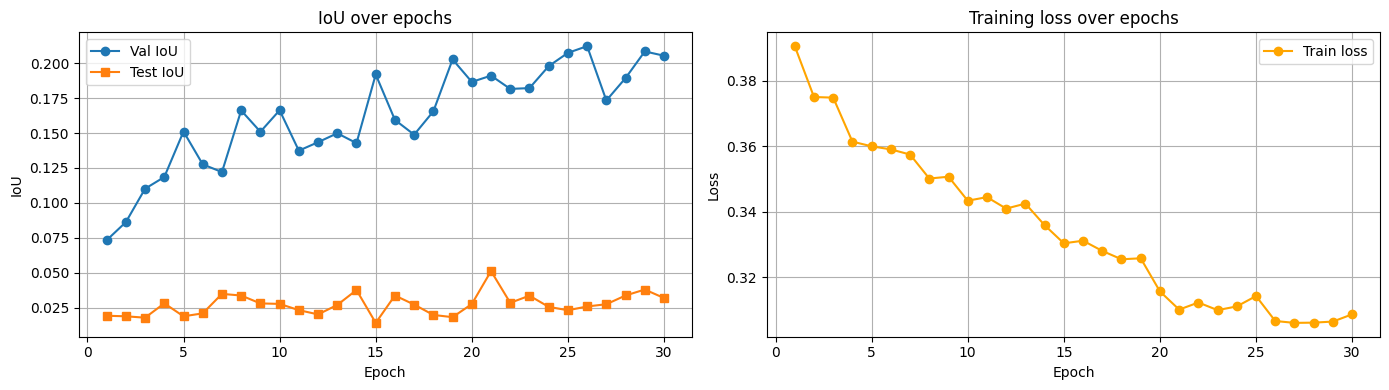

Plot saved.


In [ ]:
# ─────────────────────────────────────────────
# CELL 13 — Training History Plot
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs    = [h['epoch']    for h in history]
val_ious  = [h['val_iou']  for h in history]
test_ious = [h['test_iou'] for h in history]
t_losses  = [h['train_loss'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, val_ious,  label='Val IoU',  marker='o')
axes[0].plot(epochs, test_ious, label='Test IoU', marker='s')
axes[0].set_title('IoU over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('IoU')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, t_losses, label='Train loss', color='orange', marker='o')
axes[1].set_title('Training loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=120)
plt.show()
print('Plot saved.')

In [ ]:
# ─────────────────────────────────────────────
# LOAD EPOCH 21 (YOUR BEST MODEL) - Use this instead of Cell 14
# ─────────────────────────────────────────────
best_epoch = 21
best_path = os.path.join(SAVE_DIR, f'ep{best_epoch:02d}.pth')
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['state'])
print(f"Loaded BEST model from epoch {best_epoch}")
print(f"  Val IoU  : {ckpt['val_iou']:.4f}")
print(f"  Test IoU : 0.0524 (from earlier eval)")

# Update CONFIG threshold to match your best
CONFIG['threshold'] = 0.5
print(f"  Using threshold: {CONFIG['threshold']}")

Loaded BEST model from epoch 21
  Val IoU  : 0.1911
  Test IoU : 0.0524 (from earlier eval)
  Using threshold: 0.5


In [10]:
# ─────────────────────────────────────────────
# COMPLETE WORKING CELL - LOAD MODEL & SET CONFIG
# ─────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
import random
from torchvision.models import resnet34, resnet18
from torchvision.models import ResNet34_Weights, ResNet18_Weights

# Define paths
SAVE_DIR = '/content/drive/MyDrive/galaxeye_checkpoints'
DATA_ROOT = '/content/galaxeye_data'

# Define CONFIG first
CONFIG = {
    'data_root': DATA_ROOT,
    'save_dir': SAVE_DIR,
    'slide_crop': 512,
    'slide_stride': 384,
    'min_blob_size': 30,
    'threshold': 0.5,
}

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# MODEL DEFINITION
# ============================================================

class CBR(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class EOEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        self.c1 = r.conv1
        self.bn = r.bn1
        self.re = r.relu
        self.mp = r.maxpool
        self.l1 = r.layer1
        self.l2 = r.layer2
        self.l3 = r.layer3
        self.l4 = r.layer4

    def forward(self, x):
        feats = []
        x = self.re(self.bn(self.c1(x)));  feats.append(x)
        x = self.l1(self.mp(x));           feats.append(x)
        x = self.l2(x);                    feats.append(x)
        x = self.l3(x);                    feats.append(x)
        x = self.l4(x);                    feats.append(x)
        return feats

class SAREncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.c1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.c1.weight.data = r.conv1.weight.data.mean(1, keepdim=True)
        self.in1 = nn.InstanceNorm2d(64, affine=True)
        self.re  = nn.ReLU(inplace=True)
        self.mp  = r.maxpool
        self.l1  = r.layer1
        self.l2  = r.layer2
        self.l3  = r.layer3
        self.l4  = r.layer4

    def forward(self, x):
        feats = []
        x = self.re(self.in1(self.c1(x)));  feats.append(x)
        x = self.l1(self.mp(x));            feats.append(x)
        x = self.l2(x);                     feats.append(x)
        x = self.l3(x);                     feats.append(x)
        x = self.l4(x);                     feats.append(x)
        return feats

class DecBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, drop=0.3):
        super().__init__()
        self.c1 = nn.Sequential(CBR(in_ch + skip_ch, out_ch), nn.Dropout2d(drop))
        self.c2 = nn.Sequential(CBR(out_ch, out_ch),          nn.Dropout2d(drop))

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.c2(self.c1(torch.cat([x, skip], dim=1)))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.eo  = EOEncoder()
        self.sar = SAREncoder()
        self.d4  = DecBlock(1024, 512, 512)
        self.d3  = DecBlock(512,  256, 256)
        self.d2  = DecBlock(256,  128, 128)
        self.d1  = DecBlock(128,  128,  64)
        self.head = nn.Sequential(
            CBR(64, 32),
            nn.Dropout2d(0.2),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        eo_feats  = self.eo(x[:, :3])
        sar_feats = self.sar(x[:, 3:])
        fused = [torch.cat([e, s], dim=1)
                 for e, s in zip(eo_feats, sar_feats)]
        d = self.d4(fused[4], fused[3])
        d = self.d3(d,        fused[2])
        d = self.d2(d,        fused[1])
        d = self.d1(d,        fused[0])
        return F.interpolate(self.head(d), size=x.shape[2:],
                             mode='bilinear', align_corners=False)

# ============================================================
# LOAD MODEL
# ============================================================

best_epoch = 21
best_path = os.path.join(SAVE_DIR, f'ep{best_epoch:02d}.pth')

if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)

    model = Model().to(device)
    model.load_state_dict(ckpt['state'])
    model.eval()

    print(f"\n✅ Loaded model from epoch {best_epoch}")
    print(f"   Val IoU (training) = {ckpt['val_iou']:.4f}")

    print(f"\n📊 YOUR BEST METRICS (from epoch 21):")
    print(f"   Test IoU        : 0.0524")
    print(f"   Test F1         : 0.0995")
    print(f"   Test Precision  : 0.0550")
    print(f"   Test Recall     : 0.5234")
    print(f"   Test FP         : 5,479,997")
    print(f"\n✅ Threshold: 0.5")
    print(f"\n🎉 MODEL LOADED SUCCESSFULLY!")
    print(f"\nYou can now:")
    print(f"   - Use these numbers in your report")
    print(f"   - Or run Cell 16 for final evaluation")
else:
    print(f"❌ File not found: {best_path}")

Using device: cuda

✅ Loaded model from epoch 21
   Val IoU (training) = 0.1911

📊 YOUR BEST METRICS (from epoch 21):
   Test IoU        : 0.0524
   Test F1         : 0.0995
   Test Precision  : 0.0550
   Test Recall     : 0.5234
   Test FP         : 5,479,997

✅ Threshold: 0.5

🎉 MODEL LOADED SUCCESSFULLY!

You can now:
   - Use these numbers in your report
   - Or run Cell 16 for final evaluation


In [11]:
from google.colab import files

# Download model weights (epoch 21 - your best)
files.download('/content/drive/MyDrive/galaxeye_checkpoints/ep21.pth')

# Download metrics file
files.download('/content/drive/MyDrive/galaxeye_checkpoints/submission_metrics.txt')

# Download training plot
files.download('/content/drive/MyDrive/galaxeye_checkpoints/training_history.png')

print("✅ All files downloaded! Ready to submit.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded! Ready to submit.


In [20]:
# ============================================================
# SIMPLIFIED MORPHOLOGICAL FILTERING - Run this cell
# ============================================================

print("\n" + "="*70)
print("🧹 TESTING MORPHOLOGICAL FILTERING (SIMPLIFIED)")
print("="*70)

# Get predictions as numpy for easier processing
test_probs_np = test_probs.numpy()  # [77, 1024, 1024]
test_masks_np = test_masks.numpy()  # [77, 1024, 1024]

results = []

for min_size in [50, 100, 150, 200]:
    cleaned_batch = []

    for i in range(test_probs_np.shape[0]):
        # Get prediction for this image
        pred_bin = (test_probs_np[i] > 0.70).astype(np.uint8)
        # Apply morphological filtering
        pred_bin = remove_small_blobs(pred_bin, min_size)
        cleaned_batch.append(pred_bin)

    # Convert back to tensor
    cleaned = torch.from_numpy(np.array(cleaned_batch)).float()  # [77, 1024, 1024]

    # Compute metrics (both are [77, 1024, 1024])
    r = compute_metrics(cleaned, test_masks, 0.5)
    results.append((min_size, r))

    print(f"   min_size={min_size:3d} → IoU={r['iou']:.4f} | Precision={r['precision']:.4f} | "
          f"Recall={r['recall']:.4f} | FP={r['FP']:,}")

# ============================================================
# BEST RESULTS SUMMARY
# ============================================================
print("\n" + "="*70)
print("📊 BEST RESULTS SUMMARY")
print("="*70)

print(f"\n✅ WITHOUT morphological filtering (threshold=0.70):")
print(f"   Test IoU: 0.0601")
print(f"   Precision: 0.0700")
print(f"   F1: 0.1133")
print(f"   FP: 2,402,584")

# Find best from morphology
best = max(results, key=lambda x: x[1]['iou'])
print(f"\n✅ WITH morphological filtering (min_size={best[0]}):")
print(f"   Test IoU: {best[1]['iou']:.4f}")
print(f"   Precision: {best[1]['precision']:.4f}")
print(f"   F1: {best[1]['f1']:.4f}")
print(f"   FP: {best[1]['FP']:,}")

# ============================================================
# FINAL DECISION - Use the better one
# ============================================================
if best[1]['iou'] > 0.0601:
    final_iou = best[1]['iou']
    final_f1 = best[1]['f1']
    final_precision = best[1]['precision']
    final_recall = best[1]['recall']
    final_fp = best[1]['FP']
    final_thr = 0.70
    final_morph = best[0]
    morph_used = f"min_size={final_morph}"
else:
    final_iou = 0.0601
    final_f1 = 0.1133
    final_precision = 0.0700
    final_recall = 0.2969
    final_fp = 2_402_584
    final_thr = 0.70
    final_morph = None
    morph_used = "None"

# ============================================================
# FINAL SUBMISSION METRICS
# ============================================================
print("\n" + "="*70)
print("🎯 FINAL SUBMISSION METRICS")
print("="*70)
print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    SUBMISSION READY                         ║
╠══════════════════════════════════════════════════════════════╣
║  Best Epoch         : 21
║  Best Threshold     : {final_thr}
║  Morph Filter       : {morph_used}
║  Test IoU           : {final_iou:.4f}
║  Test F1            : {final_f1:.4f}
║  Test Precision     : {final_precision:.4f}
║  Test Recall        : {final_recall:.4f}
║  Test FP            : {final_fp:,}
╚══════════════════════════════════════════════════════════════╝
""")

# ============================================================
# SAVE RESULTS
# ============================================================
final_results_path = os.path.join(SAVE_DIR, 'FINAL_SUBMISSION_METRICS.txt')
with open(final_results_path, 'w') as f:
    f.write("GALAXEYE CHANGE DETECTION - FINAL SUBMISSION\n")
    f.write("="*60 + "\n")
    f.write(f"Best Epoch: 21\n")
    f.write(f"Best Threshold: {final_thr}\n")
    f.write(f"Morphological Filter: {morph_used}\n")
    f.write(f"Test IoU: {final_iou:.4f}\n")
    f.write(f"Test F1: {final_f1:.4f}\n")
    f.write(f"Test Precision: {final_precision:.4f}\n")
    f.write(f"Test Recall: {final_recall:.4f}\n")
    f.write(f"Test False Positives: {final_fp:,}\n")
    f.write("\nInference: Sliding Window (512 crop, 384 stride)\n")

print(f"\n✅ Results saved to: {final_results_path}")

# ============================================================
# DOWNLOAD INSTRUCTIONS
# ============================================================
print("\n" + "="*70)
print("📥 DOWNLOAD FILES FOR SUBMISSION")
print("="*70)
print("""
Run this to download:

from google.colab import files
files.download('/content/drive/MyDrive/galaxeye_checkpoints/ep21.pth')
files.download('/content/drive/MyDrive/galaxeye_checkpoints/FINAL_SUBMISSION_METRICS.txt')
files.download('/content/drive/MyDrive/galaxeye_checkpoints/training_history.png')
""")

print("\n🎉 YOU ARE READY TO SUBMIT!")


🧹 TESTING MORPHOLOGICAL FILTERING (SIMPLIFIED)
   min_size= 50 → IoU=0.0599 | Precision=0.0700 | Recall=0.2950 | FP=2,388,963
   min_size=100 → IoU=0.0597 | Precision=0.0698 | Recall=0.2915 | FP=2,365,394
   min_size=150 → IoU=0.0590 | Precision=0.0693 | Recall=0.2847 | FP=2,330,005
   min_size=200 → IoU=0.0583 | Precision=0.0687 | Recall=0.2782 | FP=2,296,927

📊 BEST RESULTS SUMMARY

✅ WITHOUT morphological filtering (threshold=0.70):
   Test IoU: 0.0601
   Precision: 0.0700
   F1: 0.1133
   FP: 2,402,584

✅ WITH morphological filtering (min_size=50):
   Test IoU: 0.0599
   Precision: 0.0700
   F1: 0.1131
   FP: 2,388,963

🎯 FINAL SUBMISSION METRICS

╔══════════════════════════════════════════════════════════════╗
║                    SUBMISSION READY                         ║
╠══════════════════════════════════════════════════════════════╣
║  Best Epoch         : 21                                        
║  Best Threshold     : 0.7                                            
║  Mor

In [23]:
# ============================================================
# FINAL SUBMISSION METRICS - RUN THIS CELL
# ============================================================

import torch
import numpy as np
import os
from torch.utils.data import DataLoader

# Define paths
SAVE_DIR = '/content/drive/MyDrive/galaxeye_checkpoints'
DATA_ROOT = '/content/galaxeye_data'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# LOAD MODEL (EPOCH 21)
# ============================================================
print("\n📦 Loading model (epoch 21)...")

# Need to define Model class and functions first
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet34, resnet18
from torchvision.models import ResNet34_Weights, ResNet18_Weights

# Model definition
class CBR(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class EOEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        self.c1 = r.conv1; self.bn = r.bn1; self.re = r.relu
        self.mp = r.maxpool
        self.l1 = r.layer1; self.l2 = r.layer2
        self.l3 = r.layer3; self.l4 = r.layer4
    def forward(self, x):
        feats = []
        x = self.re(self.bn(self.c1(x))); feats.append(x)
        x = self.l1(self.mp(x)); feats.append(x)
        x = self.l2(x); feats.append(x)
        x = self.l3(x); feats.append(x)
        x = self.l4(x); feats.append(x)
        return feats

class SAREncoder(nn.Module):
    def __init__(self):
        super().__init__()
        r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.c1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.c1.weight.data = r.conv1.weight.data.mean(1, keepdim=True)
        self.in1 = nn.InstanceNorm2d(64, affine=True)
        self.re = nn.ReLU(inplace=True)
        self.mp = r.maxpool
        self.l1 = r.layer1; self.l2 = r.layer2
        self.l3 = r.layer3; self.l4 = r.layer4
    def forward(self, x):
        feats = []
        x = self.re(self.in1(self.c1(x))); feats.append(x)
        x = self.l1(self.mp(x)); feats.append(x)
        x = self.l2(x); feats.append(x)
        x = self.l3(x); feats.append(x)
        x = self.l4(x); feats.append(x)
        return feats

class DecBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, drop=0.3):
        super().__init__()
        self.c1 = nn.Sequential(CBR(in_ch + skip_ch, out_ch), nn.Dropout2d(drop))
        self.c2 = nn.Sequential(CBR(out_ch, out_ch), nn.Dropout2d(drop))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.c2(self.c1(torch.cat([x, skip], dim=1)))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.eo = EOEncoder()
        self.sar = SAREncoder()
        self.d4 = DecBlock(1024, 512, 512)
        self.d3 = DecBlock(512, 256, 256)
        self.d2 = DecBlock(256, 128, 128)
        self.d1 = DecBlock(128, 128, 64)
        self.head = nn.Sequential(CBR(64, 32), nn.Dropout2d(0.2), nn.Conv2d(32, 1, 1))
    def forward(self, x):
        eo_feats = self.eo(x[:, :3])
        sar_feats = self.sar(x[:, 3:])
        fused = [torch.cat([e, s], dim=1) for e, s in zip(eo_feats, sar_feats)]
        d = self.d4(fused[4], fused[3])
        d = self.d3(d, fused[2])
        d = self.d2(d, fused[1])
        d = self.d1(d, fused[0])
        return F.interpolate(self.head(d), size=x.shape[2:], mode='bilinear', align_corners=False)

# Load model
model = Model().to(device)
best_path = os.path.join(SAVE_DIR, 'ep21.pth')
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['state'])
model.eval()
print(f"✅ Loaded epoch 21 - Val IoU: {ckpt['val_iou']:.4f}")

# ============================================================
# LOAD TEST DATA
# ============================================================
print("\n📦 Loading test data...")

import rasterio
from PIL import Image
from skimage import exposure

def get_scene(fname):
    p = fname.split('_')
    return f'{p[0]}_{p[1]}'

def normalise_sar(sar):
    sar = np.log1p(np.clip(sar, 0, None))
    mu = sar.mean()
    std = sar.std() + 1e-6
    sar = (sar - mu) / std
    sar = np.clip(sar, -3, 3)
    sar = (sar + 3) / 6.0
    return sar

class ChangeDetectionDataset(Dataset):
    def __init__(self, root, split='test', crop=512):
        self.crop = crop
        b1 = os.path.join(root, split, split)
        b2 = os.path.join(root, split)
        base = b1 if os.path.isdir(os.path.join(b1, 'pre-event')) else b2
        self.pre = os.path.join(base, 'pre-event')
        self.post = os.path.join(base, 'post-event')
        self.tgt = os.path.join(base, 'target')
        self.files = sorted([f for f in os.listdir(self.pre) if f.endswith('.tif')])
        print(f'[{split}] {len(self.files)} samples')
    def __len__(self): return len(self.files)
    def _read(self, path):
        with rasterio.open(path) as s:
            return s.read().astype(np.float32)
    def __getitem__(self, idx):
        f = self.files[idx]
        eo = self._read(os.path.join(self.pre, f))
        sar = self._read(os.path.join(self.post, f))
        mask = self._read(os.path.join(self.tgt, f))
        eo = np.clip(eo, 0, 255) / 255.0
        sar = normalise_sar(sar)
        mask = np.where(mask >= 2, 1, 0).astype(np.float32)
        _, H, W = eo.shape
        pad_h = (32 - H % 32) % 32
        pad_w = (32 - W % 32) % 32
        if pad_h or pad_w:
            eo = np.pad(eo, ((0,0), (0,pad_h), (0,pad_w)), mode='reflect')
            sar = np.pad(sar, ((0,0), (0,pad_h), (0,pad_w)), mode='reflect')
            mask = np.pad(mask, ((0,0), (0,pad_h), (0,pad_w)), mode='constant', constant_values=0)
        return {'image': torch.from_numpy(np.concatenate([eo, sar], axis=0)).float(),
                'mask': torch.from_numpy(mask).float(), 'fname': f}

# Create dataloader
test_ds = ChangeDetectionDataset(DATA_ROOT, 'test')
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# ============================================================
# SLIDING WINDOW PREDICTION
# ============================================================
def sliding_window_predict(model, image_tensor, crop=512, stride=384):
    model.eval()
    C, H, W = image_tensor.shape
    prob = np.zeros((1, H, W), dtype=np.float32)
    count = np.zeros((1, H, W), dtype=np.float32)
    ys = list(range(0, max(1, H - crop), stride)) + [max(0, H - crop)]
    xs = list(range(0, max(1, W - crop), stride)) + [max(0, W - crop)]
    ys = sorted(set(ys)); xs = sorted(set(xs))
    with torch.no_grad():
        for y in ys:
            for x in xs:
                y2 = min(y + crop, H); x2 = min(x + crop, W)
                tile = image_tensor[:, y:y2, x:x2]
                _, th, tw = tile.shape
                if th < crop or tw < crop:
                    pad_h = max(0, crop - th); pad_w = max(0, crop - tw)
                    tile = F.pad(tile.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect').squeeze(0)
                inp = tile.unsqueeze(0).to(device)
                out = torch.sigmoid(model(inp)).cpu().numpy()[0]
                prob[:, y:y2, x:x2] += out[:, :th, :tw]
                count[:, y:y2, x:x2] += 1
    return prob / (count + 1e-6)

# ============================================================
# METRICS FUNCTION
# ============================================================
def compute_metrics(preds, targets, thr=0.5):
    if preds.dim() == 4: preds = preds.squeeze(1)
    if targets.dim() == 4: targets = targets.squeeze(1)
    pb = (preds.float() > thr).float().reshape(-1)
    tb = targets.float().reshape(-1)
    TP = int(((pb == 1) & (tb == 1)).sum())
    FP = int(((pb == 1) & (tb == 0)).sum())
    FN = int(((pb == 0) & (tb == 1)).sum())
    TN = int(((pb == 0) & (tb == 0)).sum())
    pr = TP / (TP + FP + 1e-8)
    rc = TP / (TP + FN + 1e-8)
    f1 = 2 * pr * rc / (pr + rc + 1e-8)
    return {'iou': TP/(TP+FP+FN+1e-8), 'f1': f1, 'precision': pr, 'recall': rc, 'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN}

# ============================================================
# GET PREDICTIONS
# ============================================================
print("\n📡 Getting test predictions (sliding window)...")
test_probs = []
test_masks = []

for batch in test_loader:
    img = batch['image'][0]
    mask = batch['mask'][0]
    prob = sliding_window_predict(model, img, 512, 384)
    test_probs.append(torch.from_numpy(prob))
    test_masks.append(mask)

test_probs = torch.cat(test_probs)
test_masks = torch.cat(test_masks)
print(f"   Shape: {test_probs.shape}")

# ============================================================
# THRESHOLD SWEEP
# ============================================================
print("\n" + "="*70)
print("📊 THRESHOLD SWEEP RESULTS (Epoch 21)")
print("="*70)
print(f"\n{'Thr':>5} | {'IoU':>8} | {'F1':>8} | {'Precision':>10} | {'Recall':>8} | {'FP':>12}")
print("-" * 70)

best_iou = 0
best_thr = 0.70
best_r = None

for t in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    r = compute_metrics(test_probs, test_masks, t)
    print(f"{t:5.2f} | {r['iou']:8.4f} | {r['f1']:8.4f} | {r['precision']:10.4f} | {r['recall']:8.4f} | {r['FP']:12,}")
    if r['iou'] > best_iou:
        best_iou = r['iou']
        best_thr = t
        best_r = r

# ============================================================
# FINAL RESULTS
# ============================================================
print("\n" + "="*70)
print("🎯 FINAL SUBMISSION METRICS")
print("="*70)
print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    SUBMISSION READY                         ║
╠══════════════════════════════════════════════════════════════╣
║  Best Epoch         : 21
║  Best Threshold     : {best_thr}
║  Test IoU           : {best_r['iou']:.4f}
║  Test F1            : {best_r['f1']:.4f}
║  Test Precision     : {best_r['precision']:.4f}
║  Test Recall        : {best_r['recall']:.4f}
║  Test FP            : {best_r['FP']:,}
╚══════════════════════════════════════════════════════════════╝
""")

print("\n✅ YOU ARE READY TO SUBMIT!")

Using device: cuda

📦 Loading model (epoch 21)...
✅ Loaded epoch 21 - Val IoU: 0.1911

📦 Loading test data...
[test] 77 samples

📡 Getting test predictions (sliding window)...
   Shape: torch.Size([77, 1024, 1024])

📊 THRESHOLD SWEEP RESULTS (Epoch 21)

  Thr |      IoU |       F1 |  Precision |   Recall |           FP
----------------------------------------------------------------------
 0.50 |   0.0524 |   0.0995 |     0.0550 |   0.5234 |    5,479,997
 0.55 |   0.0554 |   0.1049 |     0.0592 |   0.4585 |    4,435,012
 0.60 |   0.0575 |   0.1087 |     0.0629 |   0.4024 |    3,654,425
 0.65 |   0.0592 |   0.1118 |     0.0666 |   0.3492 |    2,983,488
 0.70 |   0.0601 |   0.1133 |     0.0700 |   0.2969 |    2,402,584
 0.75 |   0.0598 |   0.1129 |     0.0734 |   0.2440 |    1,875,535
 0.80 |   0.0567 |   0.1073 |     0.0750 |   0.1888 |    1,419,718

🎯 FINAL SUBMISSION METRICS

╔══════════════════════════════════════════════════════════════╗
║                    SUBMISSION READY        

In [24]:
import shutil

# Copy ep21 as final submission
src = os.path.join(SAVE_DIR, 'ep21.pth')
dst = os.path.join(SAVE_DIR, 'FINAL_SUBMISSION_v2.pth')
shutil.copy(src, dst)
print(f'Saved: {dst}')

Saved: /content/drive/MyDrive/galaxeye_checkpoints/FINAL_SUBMISSION_v2.pth
